In [30]:
library(DESeq2)
library(ggplot2)

In [25]:
dds_24h <- readRDS("Apartado2/output/dds.rds")
metadata_24h <- readRDS("Apartado2/output/metadata_dds.rds")

In [41]:
metadata_24h

,patient,agent,time
,<fct>,<fct>,<fct>
GSM913873,1,Control,24h
GSM913875,1,DPN,24h
GSM913877,1,OHT,24h
GSM913879,2,Control,24h
GSM913881,2,DPN,24h
GSM913883,2,OHT,24h
GSM913885,3,Control,24h
GSM913887,3,DPN,24h
GSM913889,3,OHT,24h


In [26]:
res_24h <- results(dds_24h, 
                    contrast = c("agent", "DPN", "Control"),
                    alpha = 0.05,
                    lfcThreshold = 0,#1,
                    pAdjustMethod = "BH"
                )
summary(res_24h)


out of 24411 with nonzero total read count
adjusted p-value < 0.05
LFC > 0 (up)       : 12, 0.049%
LFC < 0 (down)     : 20, 0.082%
outliers [1]       : 0, 0%
low counts [2]     : 18457, 76%
(mean count < 329)
[1] see 'cooksCutoff' argument of ?results
[2] see 'independentFiltering' argument of ?results



In [27]:
resultsNames(dds_24h)

[1] "Intercept"            "patient_2_vs_1"       "patient_3_vs_1"      
[4] "patient_4_vs_1"       "agent_DPN_vs_Control" "agent_OHT_vs_Control"

In [32]:
BiocManager::install("apeglm")

'getOption("repos")' replaces Bioconductor standard repositories, see
'help("repositories", package = "BiocManager")' for details.
Replacement repositories:
    CRAN: https://cran.r-project.org

Bioconductor version 3.20 (BiocManager 1.30.27), R 4.4.1 (2024-06-14)

Installing package(s) 'apeglm'

also installing the dependencies ‘numDeriv’, ‘bdsmatrix’, ‘mvtnorm’, ‘coda’, ‘bbmle’, ‘emdbook’, ‘RcppNumerical’


Updating HTML index of packages in '.Library'

Making 'packages.html' ...
 done

Old packages: 'fs', 'ggrepel', 'highr', 'png', 'RcppArmadillo', 'xfun', 'XML'



In [33]:
res_24h.ape <- lfcShrink(dds_24h, coef = "agent_DPN_vs_Control", 
                        type = "apeglm",
                     res = res_24h)
head(res_24h.ape)

using 'apeglm' for LFC shrinkage. If used in published research, please cite:
    Zhu, A., Ibrahim, J.G., Love, M.I. (2018) Heavy-tailed prior distributions for
    sequence count data: removing the noise and preserving large differences.
    Bioinformatics. https://doi.org/10.1093/bioinformatics/bty895



log2 fold change (MAP): agent DPN vs Control 
Wald test p-value: agent DPN vs Control 
DataFrame with 6 rows and 5 columns
                 baseMean log2FoldChange     lfcSE    pvalue      padj
                <numeric>      <numeric> <numeric> <numeric> <numeric>
ENSG00000000003 544.60224    5.74070e-03 0.0238034  0.284284  0.950142
ENSG00000000005   1.10882   -3.06384e-05 0.0234149  0.747585        NA
ENSG00000000419 248.81488   -5.93286e-03 0.0241270  0.161174        NA
ENSG00000000457 183.62554   -2.99287e-03 0.0233932  0.380137        NA
ENSG00000000460 446.16274    1.77540e-03 0.0229649  0.716048  0.982172
ENSG00000000938   9.16644    3.33639e-05 0.0233997  0.935966        NA

In [34]:
summary(res_24h.ape) # Same number of up/down genes padj < 0.05


out of 24411 with nonzero total read count
adjusted p-value < 0.05
LFC > 0 (up)       : 12, 0.049%
LFC < 0 (down)     : 20, 0.082%
outliers [1]       : 0, 0%
low counts [2]     : 18457, 76%
(mean count < 329)
[1] see 'cooksCutoff' argument of ?results
[2] see 'independentFiltering' argument of ?results



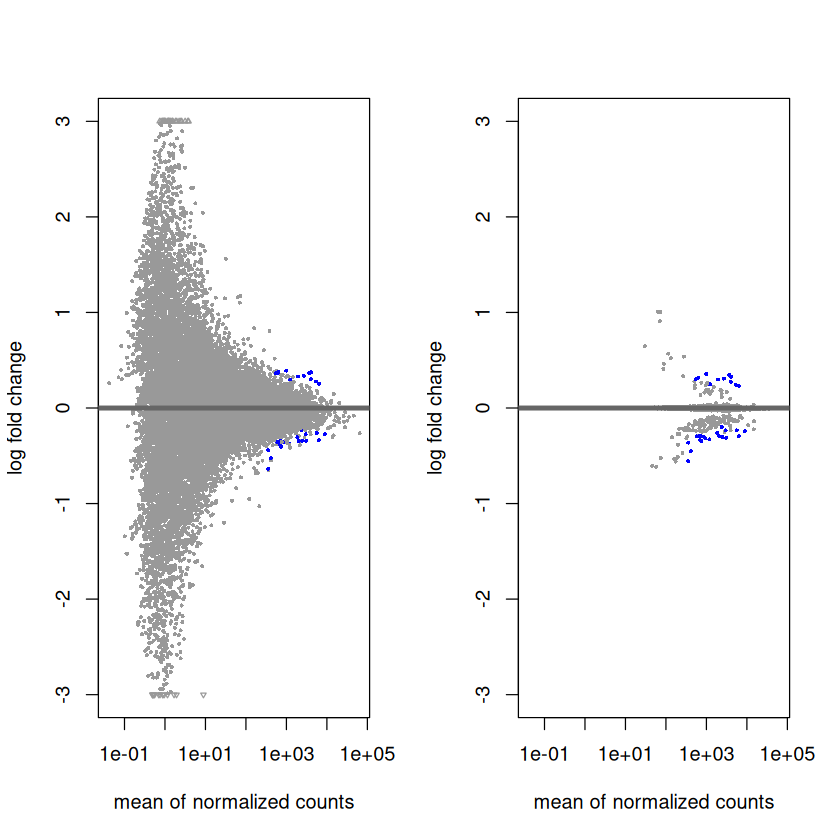

In [35]:
par(mfrow = c(1, 2),  bg = "white")
plotMA(res_24h, ylim = c(-3, 3))
plotMA(res_24h.ape, ylim = c(-3, 3)) 

In [36]:
rnk <- data.frame(Feature = rownames(res_24h.ape), Stat = res_24h$stat)
head(rnk)

,Feature,Stat
,<chr>,<dbl>
1,ENSG00000000003,1.07074626
2,ENSG00000000005,-0.32182545
3,ENSG00000000419,-1.40113443
4,ENSG00000000457,-0.87764433
5,ENSG00000000460,0.36374505
6,ENSG00000000938,0.08034134


In [46]:
# Save .rnk (without header and tab separated)
write.table(rnk, file = "Apartado2/output/24h_preranked.rnk", sep = "\t", quote = FALSE, 
            col.names = FALSE, row.names = FALSE)

### GSEA Classic

In [42]:
meta_agent <- metadata_24h$agent # Sample names
meta_agent

[1] Control DPN     OHT     Control DPN     OHT     Control DPN     OHT    
[10] DPN     OHT    
Levels: Control DPN OHT

In [43]:
output.cls <- function(metacolumn, filename) {
  out <- as.vector(metacolumn)
  lvls <- levels(factor(metacolumn, levels = unique(out)))
  cat(c(length(out), length(lvls), 1, "\n"), sep = " ", file = filename)
  cat(c("#", lvls, "\n"), sep = " ", file = filename, append = TRUE)
  cat(out, sep = " ", file = filename, append = TRUE)
}

In [44]:
output.cls(meta_agent, "Apartado2/output/agent.cls")